In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 


In [ ]:
df = pd.read_csv(
   "/Users/diyakadakia/Desktop/ml2-final-project/data/Time series data.csv",
    low_memory=False,
)
print(df['Created Date'].min())
print(df['Created Date'].max())


01/01/2020 01:00:28 AM
12/31/2025 12:59:58 AM


In [ ]:
# clean
df = df.rename(columns={
    'Problem (formerly Complaint Type)': 'complaint_type',
    'Created Date': 'created_date',
    'Closed Date': 'closed_date'
})

df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])

df['complaint_type'] = df['complaint_type'].str.upper()
print(df['complaint_type'].value_counts())

complaint_type
NOISE - RESIDENTIAL        2380386
HEAT/HOT WATER             1613064
NOISE - STREET/SIDEWALK    1049279
RODENT                      225224
Name: count, dtype: int64


In [8]:
# weekly
weekly = (df.groupby([pd.Grouper(key='created_date', freq='W'), 'complaint_type'])
            .size()
            .reset_index(name='count'))

print(weekly.head(5))

  created_date           complaint_type  count
0   2020-01-05           HEAT/HOT WATER   3198
1   2020-01-05      NOISE - RESIDENTIAL   3782
2   2020-01-05  NOISE - STREET/SIDEWALK    553
3   2020-01-05                   RODENT    266
4   2020-01-12           HEAT/HOT WATER   5255


In [9]:
types = [
    'NOISE - RESIDENTIAL',
    'HEAT/HOT WATER',
    'NOISE - STREET/SIDEWALK',
    'RODENT'
]

df = df[df['complaint_type'].isin(types)]

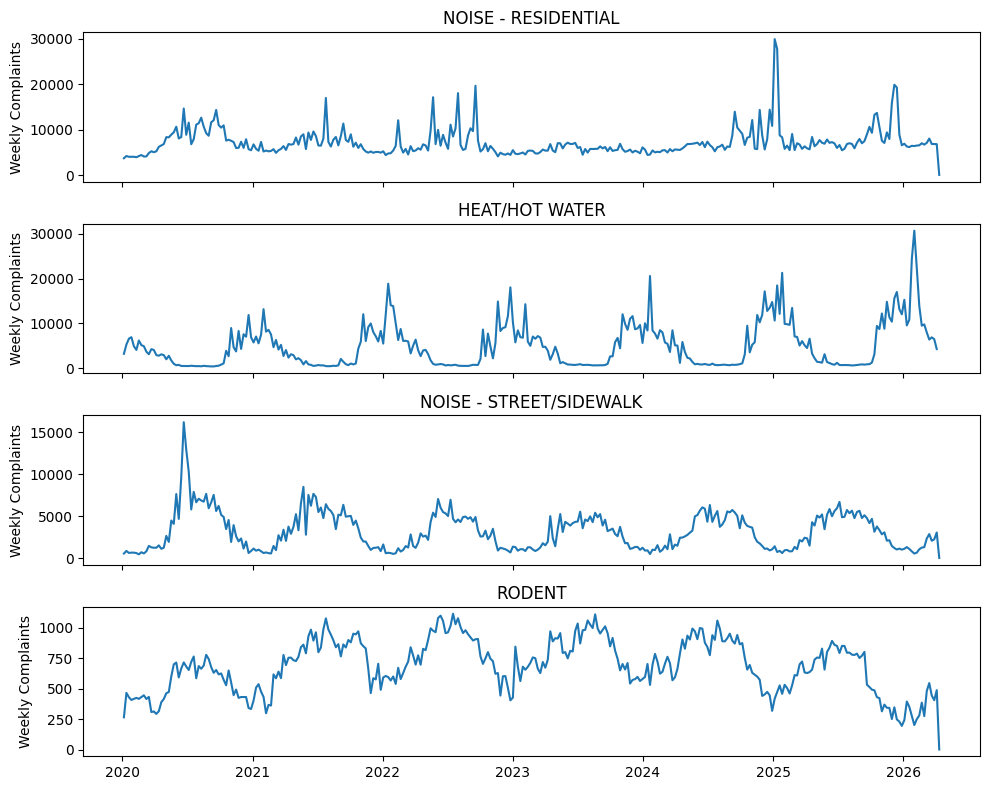

In [21]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for ax, ctype in zip(axes, types):
    data = weekly[weekly['complaint_type'] == ctype]
    ax.plot(data['created_date'], data['count'])
    ax.set_title(ctype)
    ax.set_ylabel('Weekly Complaints')

plt.tight_layout()
plt.show() 

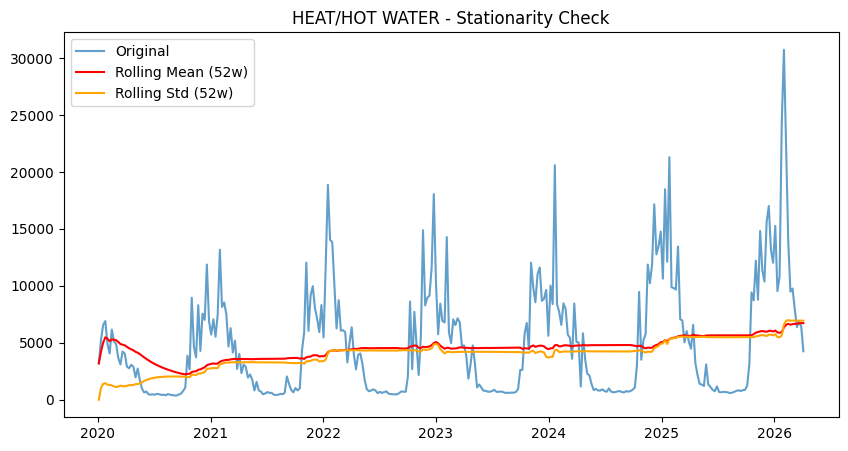

In [22]:
# isolate one series as a numpy array
heat = weekly[weekly['complaint_type'] == 'HEAT/HOT WATER'].copy()
heat = heat.sort_values('created_date').reset_index(drop=True)
y = heat['count'].values 

# rolling mean and std manually (52 weeks in one year)
window = 52  

rolling_mean = np.array([np.mean(y[max(0, i-window):i]) for i in range(1, len(y)+1)])
rolling_std = np.array([np.std(y[max(0, i-window):i]) for i in range(1, len(y)+1)])

# plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(heat['created_date'], y, label='Original', alpha=0.7)
ax.plot(heat['created_date'], rolling_mean, label='Rolling Mean (52w)', color='red')
ax.plot(heat['created_date'], rolling_std, label='Rolling Std (52w)', color='orange')
ax.legend()
ax.set_title('HEAT/HOT WATER - Stationarity Check')
plt.show()

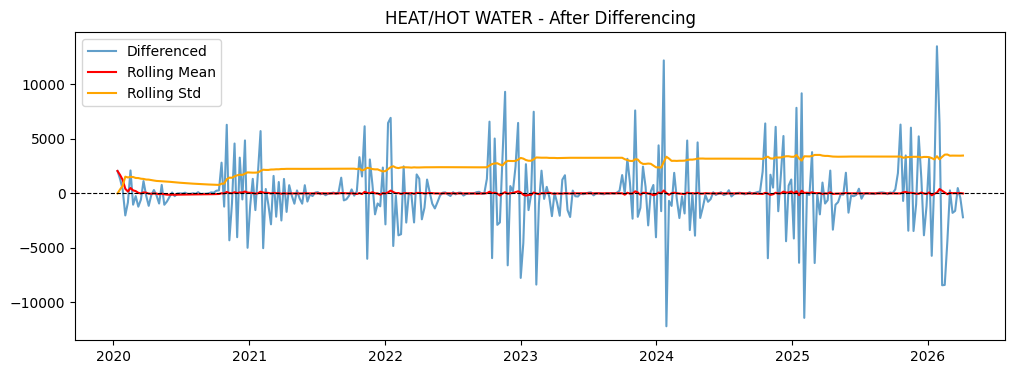

In [28]:
# first order differencing 
y_diff = np.diff(y, n=1)  # y[t] - y[t-1]

# recheck stationarity on differenced series
rolling_mean_diff = np.array([np.mean(y_diff[max(0, i-52):i]) for i in range(1, len(y_diff)+1)])
rolling_std_diff = np.array([np.std(y_diff[max(0, i-52):i]) for i in range(1, len(y_diff)+1)])

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(heat['created_date'].iloc[1:], y_diff, label='Differenced', alpha=0.7)
ax.plot(heat['created_date'].iloc[1:], rolling_mean_diff, label='Rolling Mean', color='red')
ax.plot(heat['created_date'].iloc[1:], rolling_std_diff, label='Rolling Std', color='orange')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.legend()
ax.set_title('HEAT/HOT WATER - After Differencing')
plt.show()

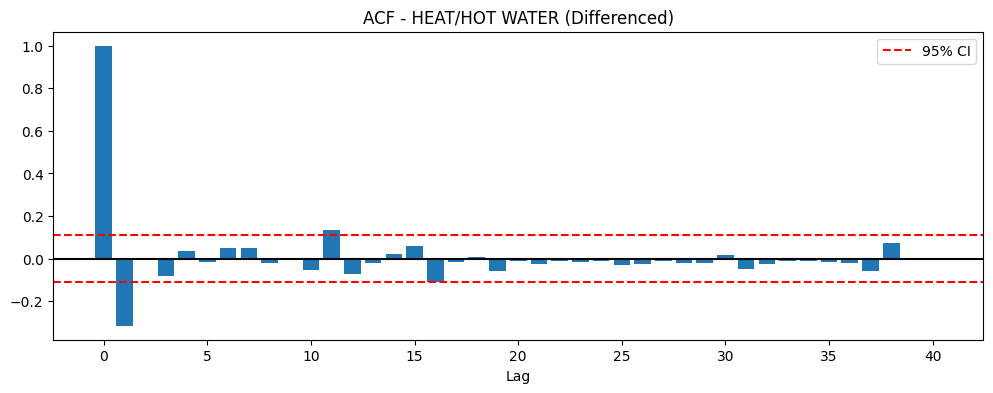

In [27]:
# acf
def acf_manual(y, max_lag=40):
    n = len(y)
    mean = np.mean(y)
    var = np.var(y)
    acf_vals = []
    for lag in range(max_lag + 1):
        cov = np.mean((y[:n-lag] - mean) * (y[lag:] - mean)) if lag > 0 else var
        acf_vals.append(cov / var)
    return np.array(acf_vals)

# compute on differenced series
heat = weekly[weekly['complaint_type'] == 'HEAT/HOT WATER'].copy()
heat = heat.sort_values('created_date').reset_index(drop=True)
y = heat['count'].values.astype(float)
y_diff = np.diff(y, n=1).astype(float)

acf_vals = acf_manual(y_diff, max_lag=40)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(acf_vals)), acf_vals)
ax.axhline(0, color='black')
ax.axhline(1.96/np.sqrt(len(y_diff)), color='red', linestyle='--', label='95% CI')
ax.axhline(-1.96/np.sqrt(len(y_diff)), color='red', linestyle='--')
ax.set_title('ACF - HEAT/HOT WATER (Differenced)')
ax.set_xlabel('Lag')
ax.legend()
plt.show()

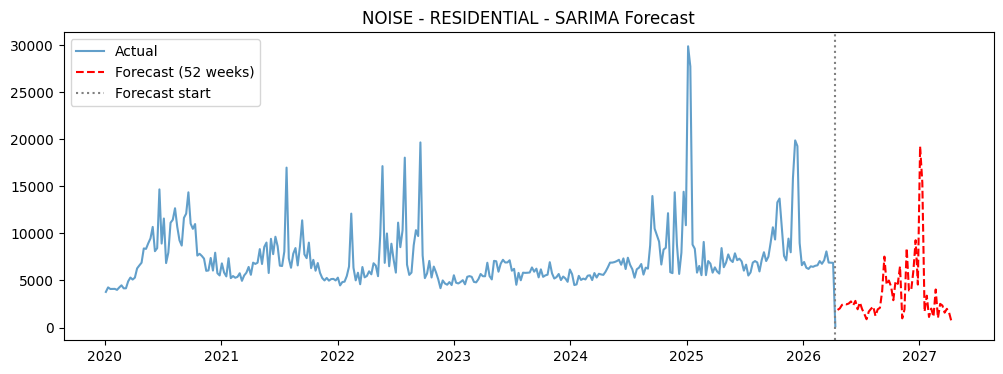

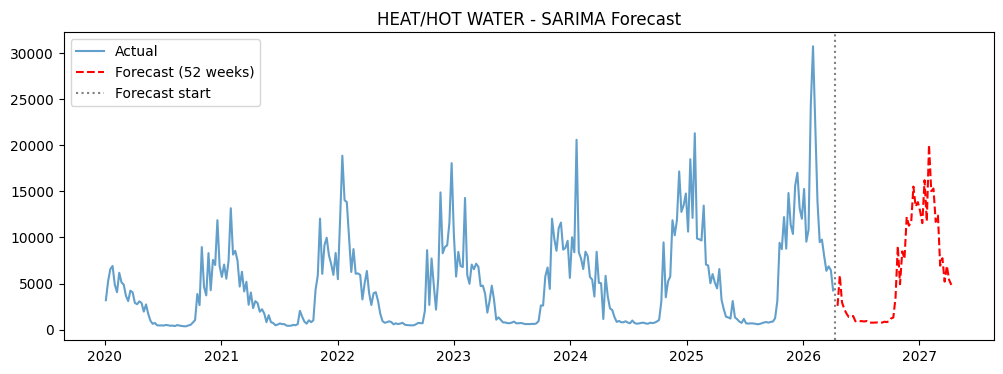

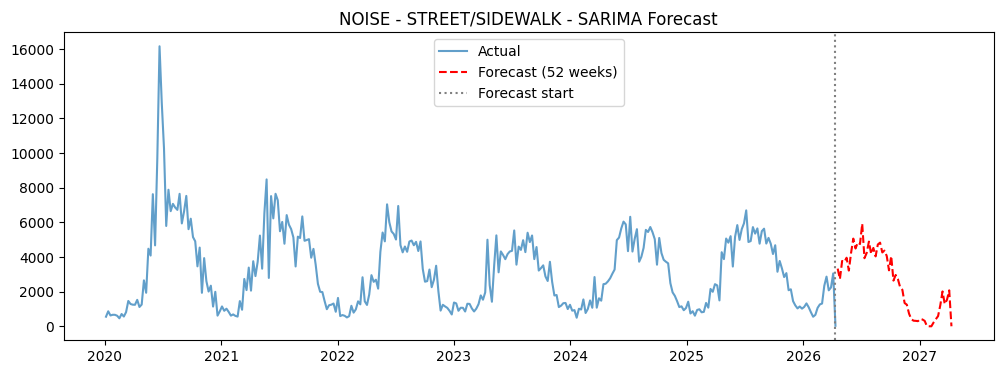

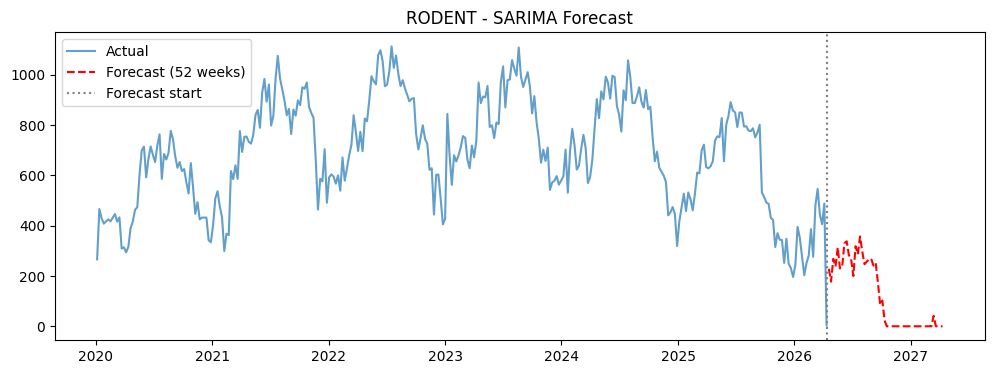

In [30]:
# fit sarima function
def fit_sarima(y, p=1, d=1, q=1, P=1, D=1, Q=1, s=52):
    y = y.astype(float)
    
    # regular differencing
    y_diff = np.diff(y, n=d)
    
    # seasonal differencing
    y_sdiff = y_diff[s:] - y_diff[:-s]
    
    n = len(y_sdiff)
    max_lag = max(p, q, s*P, s*Q)
    start = max_lag
    
    if start >= n:
        raise ValueError("Not enough data for these parameters")
    
    # build feature matrix: AR + SAR terms
    X_rows = []
    y_target = []
    
    for t in range(start, n):
        row = []
        # AR terms
        for i in range(1, p+1):
            row.append(y_sdiff[t-i])
        # SAR terms
        for i in range(1, P+1):
            row.append(y_sdiff[t - i*s] if t - i*s >= 0 else 0)
        X_rows.append(row)
        y_target.append(y_sdiff[t])
    
    X = np.array(X_rows)
    y_target = np.array(y_target)
    
    # OLS fit
    XtX = X.T @ X + np.eye(X.shape[1]) * 1e-8
    coefs = np.linalg.solve(XtX, X.T @ y_target)
    
    residuals = y_target - X @ coefs
    
    # fit MA on residuals
    X_ma_rows = []
    ma_target = []
    for t in range(max(q, Q*s), len(residuals)):
        row = []
        for i in range(1, q+1):
            row.append(residuals[t-i])
        for i in range(1, Q+1):
            idx = t - i*s
            row.append(residuals[idx] if idx >= 0 else 0)
        X_ma_rows.append(row)
        ma_target.append(residuals[t])
    
    X_ma = np.array(X_ma_rows)
    ma_target = np.array(ma_target)
    XtX_ma = X_ma.T @ X_ma + np.eye(X_ma.shape[1]) * 1e-8
    ma_coefs = np.linalg.solve(XtX_ma, X_ma.T @ ma_target)
    
    return coefs, ma_coefs, y_sdiff, y_diff, residuals

# forecast sarima function
def forecast_sarima(y, coefs, ma_coefs, residuals, p=1, d=1, q=1, P=1, D=1, Q=1, s=52, n_steps=52):
    y = y.astype(float)
    y_diff = list(np.diff(y, n=d))
    y_sdiff = list(np.array(y_diff[s:]) - np.array(y_diff[:-s]))
    res = list(residuals)
    
    future_sdiff = []
    
    for _ in range(n_steps):
        n = len(y_sdiff)
        row = []
        for i in range(1, p+1):
            row.append(y_sdiff[n-i])
        for i in range(1, P+1):
            idx = n - i*s
            row.append(y_sdiff[idx] if idx >= 0 else 0)
        
        ar_pred = np.dot(row, coefs)
        
        ma_row = []
        for i in range(1, q+1):
            ma_row.append(res[-i])
        for i in range(1, Q+1):
            idx = len(res) - i*s
            ma_row.append(res[idx] if idx >= 0 else 0)
        
        ma_pred = np.dot(ma_row, ma_coefs)
        
        next_sdiff = ar_pred + ma_pred
        future_sdiff.append(next_sdiff)
        y_sdiff.append(next_sdiff)
        res.append(0.0)
    
    # undifference: reverse seasonal diff then regular diff
    # rebuild full y_sdiff including future
    full_sdiff = list(np.array(y_diff[s:]) - np.array(y_diff[:-s])) + future_sdiff
    
    # reverse seasonal differencing
    full_ydiff = list(y_diff[:s])
    for i in range(len(full_sdiff)):
        full_ydiff.append(full_sdiff[i] + full_ydiff[-s])
    
    # reverse regular differencing
    full_y = [y[0]]
    for diff_val in full_ydiff:
        full_y.append(full_y[-1] + diff_val)
    
    future_vals = full_y[-n_steps:]
    return np.array(future_vals)

# run for all types
last_date = weekly['created_date'].max()
future_dates = pd.date_range(start=last_date, periods=53, freq='W')[1:]

for t in types:
    data = weekly[weekly['complaint_type'] == t].copy().sort_values('created_date').reset_index(drop=True)
    y = data['count'].values.astype(float)
    
    coefs, ma_coefs, y_sdiff, y_diff, residuals = fit_sarima(y)
    future = np.clip(forecast_sarima(y, coefs, ma_coefs, residuals), 0, None)

    
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(data['created_date'], y, label='Actual', alpha=0.7)
    ax.plot(future_dates, future, label='Forecast (52 weeks)', color='red', linestyle='--')
    ax.axvline(last_date, color='gray', linestyle=':', label='Forecast start')
    ax.set_title(f'{t} - SARIMA Forecast')
    ax.legend()
    plt.show()


NOISE - RESIDENTIAL
AR coefs: [-0.35580711 -0.50578236], MA coefs: [-0.09733796 -0.13870795]
Test MAE: 6525.31, RMSE: 7147.05, MAPE: 258.58%


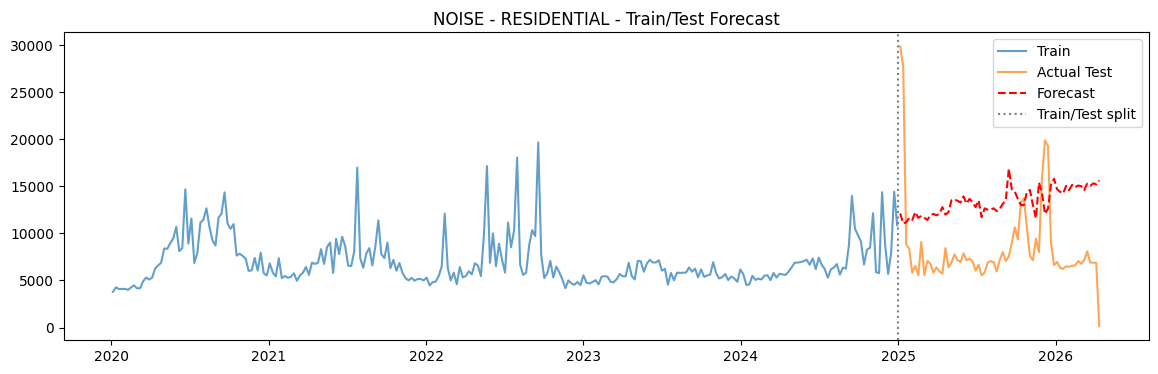


HEAT/HOT WATER
AR coefs: [-0.26012616 -0.61373448], MA coefs: [-0.32763533 -0.31164933]
Test MAE: 3281.46, RMSE: 4491.30, MAPE: 142.84%


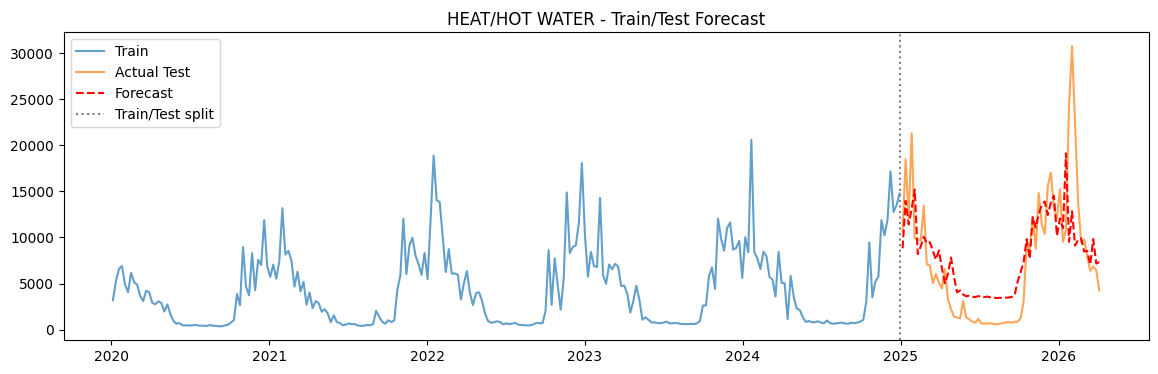


NOISE - STREET/SIDEWALK
AR coefs: [-0.3817892  -0.17722001], MA coefs: [-0.1968754  -0.12494022]
Test MAE: 679.28, RMSE: 923.61, MAPE: 164.93%


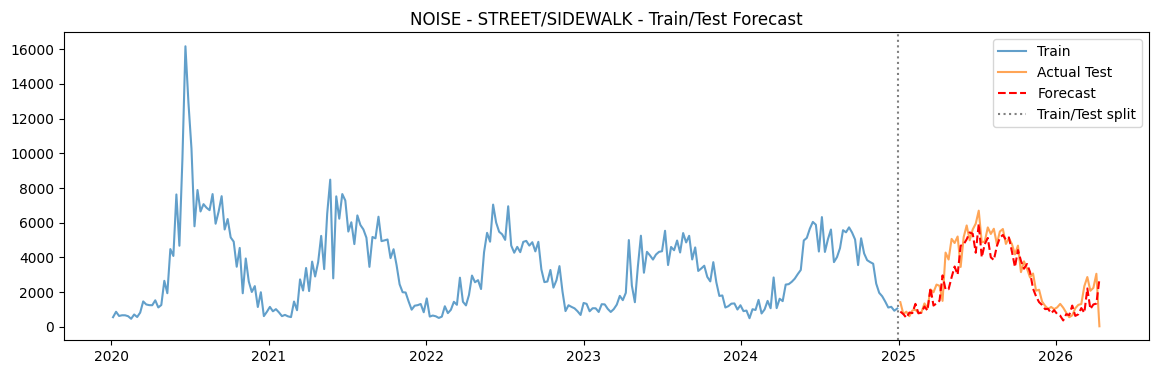


RODENT
AR coefs: [-0.20652366 -0.55179118], MA coefs: [-0.05424908 -0.19705261]
Test MAE: 111.24, RMSE: 150.52, MAPE: 346.38%


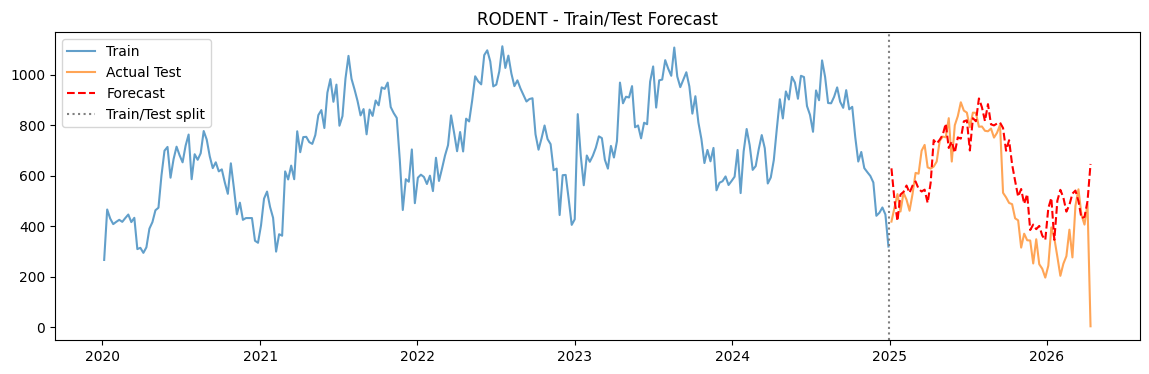

In [ ]:
# Section 1: Volume Forecasting Time Series

train_cutoff = '2024-12-31'

results = []

for t in types:
    data = weekly[weekly['complaint_type'] == t].copy().sort_values('created_date').reset_index(drop=True)
    
    train = data[data['created_date'] <= train_cutoff]
    test = data[data['created_date'] > train_cutoff]
    
    y_train = train['count'].values.astype(float)
    y_test = test['count'].values.astype(float)
    
    # fit on train
    coefs, ma_coefs, y_sdiff, y_diff, residuals = fit_sarima(y_train)
    
    # forecast n_steps: length of test set
    future = np.clip(forecast_sarima(y_train, coefs, ma_coefs, residuals, n_steps=len(y_test)), 0, None)
    
    # metrics
    mae = np.mean(np.abs(y_test - future))
    rmse = np.sqrt(np.mean((y_test - future)**2))
    mape = np.mean(np.abs((y_test - future) / (y_test + 1e-8))) * 100
    
    print(f"\n{t}")  
    print(f"AR coefs: {coefs}, MA coefs: {ma_coefs}")
    print(f"Test MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")
    
    results.append({'type': t, 'mae': mae, 'rmse': rmse, 'mape': mape, 'ar': coefs, 'ma': ma_coefs})
    
    # plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['created_date'], y_train, label='Train', alpha=0.7)
    ax.plot(test['created_date'], y_test, label='Actual Test', alpha=0.7)
    ax.plot(test['created_date'], future, label='Forecast', color='red', linestyle='--')
    ax.axvline(pd.Timestamp(train_cutoff), color='gray', linestyle=':', label='Train/Test split')
    ax.set_title(f'{t} - Train/Test Forecast')
    ax.legend()
    plt.show() 


NOISE - RESIDENTIAL
AR coefs: [-0.31746176 -0.43050039], MA coefs: [-0.11715945 -0.22147578]
Test MAE: 4.65 hours, RMSE: 7.36 hours


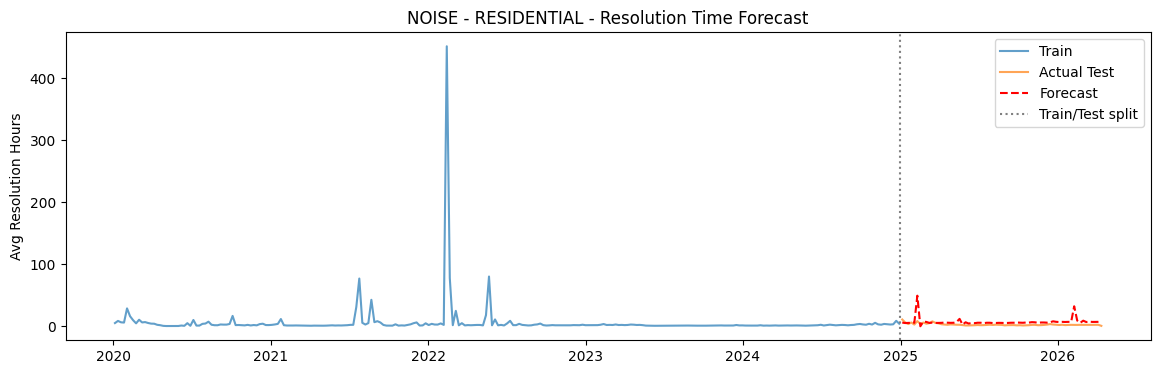


HEAT/HOT WATER
AR coefs: [-0.07313055 -0.47988297], MA coefs: [-0.20532663 -0.1571099 ]
Test MAE: 9.39 hours, RMSE: 13.27 hours


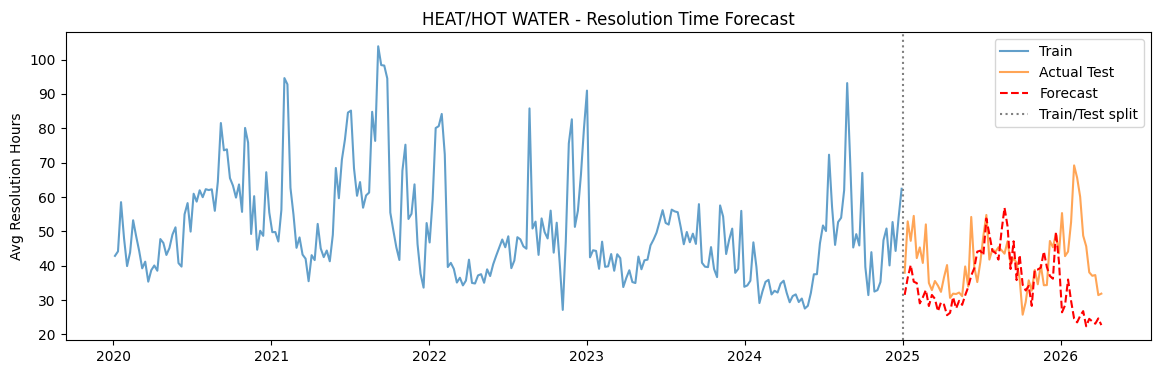


NOISE - STREET/SIDEWALK
AR coefs: [-0.29984463 -0.40841806], MA coefs: [-0.33082501  0.14755896]
Test MAE: 1.22 hours, RMSE: 1.40 hours


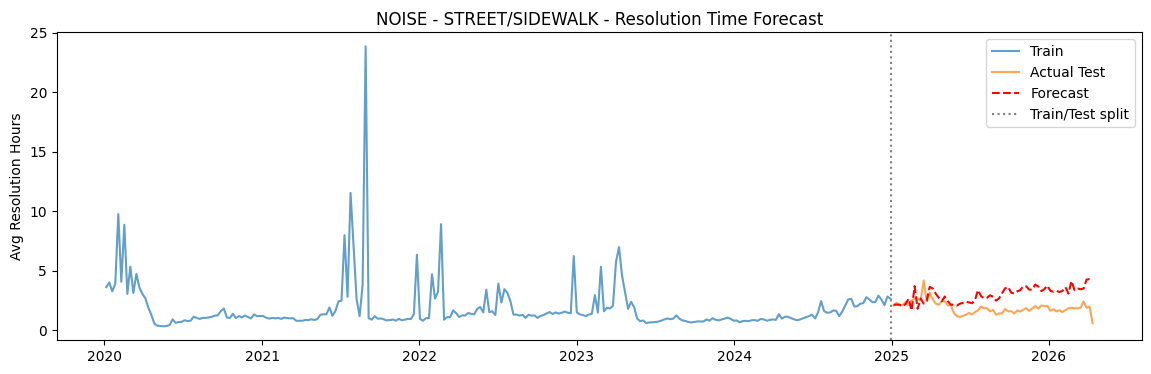


RODENT
AR coefs: [ 0.02784986 -0.06734126], MA coefs: [-0.15117066 -0.21179463]
Test MAE: 32.91 hours, RMSE: 40.86 hours


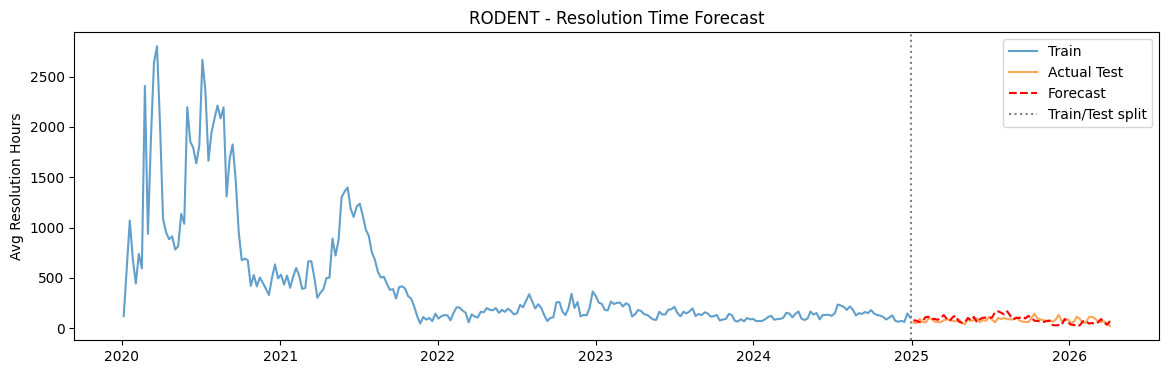

In [ ]:
# Section 2: Resolution Time Time Series

# compute resolution hours
df['resolution_hours'] = (df['closed_date'] - df['created_date']).dt.total_seconds() / 3600

# filter outliers: must be positive and under 1 year
df_res = df[(df['resolution_hours'] > 0) & (df['resolution_hours'] < 8760)]

# aggregate to weekly avg resolution time per complaint type
weekly_res = (df_res.groupby([pd.Grouper(key='created_date', freq='W'), 'complaint_type'])['resolution_hours']
                .mean()
                .reset_index(name='avg_resolution_hours'))
 

# train/test split + SARIMA per complaint type
train_cutoff = '2024-12-31'
results_res = []   

for t in types: 
    data = weekly_res[weekly_res['complaint_type'] == t].copy().sort_values('created_date').reset_index(drop=True)
    
    train = data[data['created_date'] <= train_cutoff]
    test = data[data['created_date'] > train_cutoff]
    
    y_train = train['avg_resolution_hours'].values.astype(float)
    y_test = test['avg_resolution_hours'].values.astype(float)
    
    coefs, ma_coefs, y_sdiff, y_diff, residuals = fit_sarima(y_train)
    future = np.clip(forecast_sarima(y_train, coefs, ma_coefs, residuals, n_steps=len(y_test)), 0, None)
        
    mae = np.mean(np.abs(y_test - future))
    rmse = np.sqrt(np.mean((y_test - future)**2))
        
    print(f"\n{t}")
    print(f"AR coefs: {coefs}, MA coefs: {ma_coefs}")
    print(f"Test MAE: {mae:.2f} hours, RMSE: {rmse:.2f} hours")
        
    results_res.append({'type': t, 'mae': mae, 'rmse': rmse, 'ar': coefs, 'ma': ma_coefs})
        
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['created_date'], y_train, label='Train', alpha=0.7)
    ax.plot(test['created_date'], y_test, label='Actual Test', alpha=0.7)
    ax.plot(test['created_date'], future, label='Forecast', color='red', linestyle='--')
    ax.axvline(pd.Timestamp(train_cutoff), color='gray', linestyle=':', label='Train/Test split')
    ax.set_title(f'{t} - Resolution Time Forecast')
    ax.set_ylabel('Avg Resolution Hours')
    ax.legend()
    plt.show() 